<a href="https://colab.research.google.com/github/pravee827/AI-ML/blob/main/task6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 Rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Dataset Shape:
(150, 5)
K = 1  Accuracy = 0.9667
K = 2  Accuracy = 0.9333
K = 3  Accuracy = 0.9333
K = 4  Accuracy = 0.9333
K = 5  Accuracy = 0.9333
K = 6  Accuracy = 0.9333
K = 7  Accuracy = 0.9667
K = 8  Accuracy = 0.9333
K = 9  Accuracy = 0.9667
K = 10  Accuracy = 0.9667
K = 11  Accuracy = 0.9667
K = 12  Accuracy = 0.9667
K = 13  Accuracy = 0.9667
K = 14  Accuracy = 0.9667
K = 15  Accuracy = 0.9667

Best K: 1

Final Accuracy:
96.67

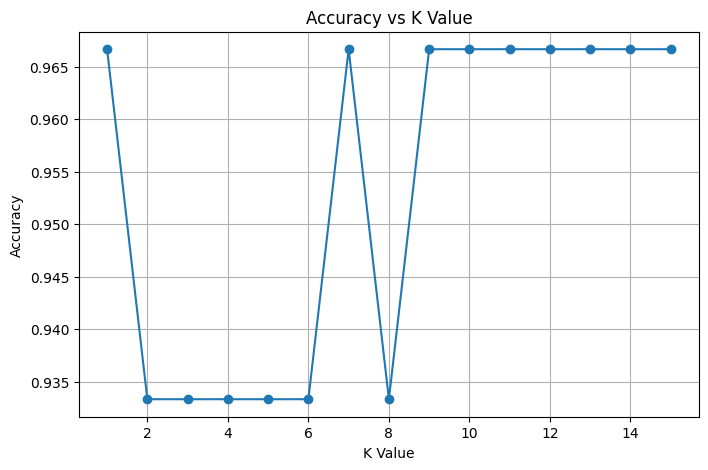

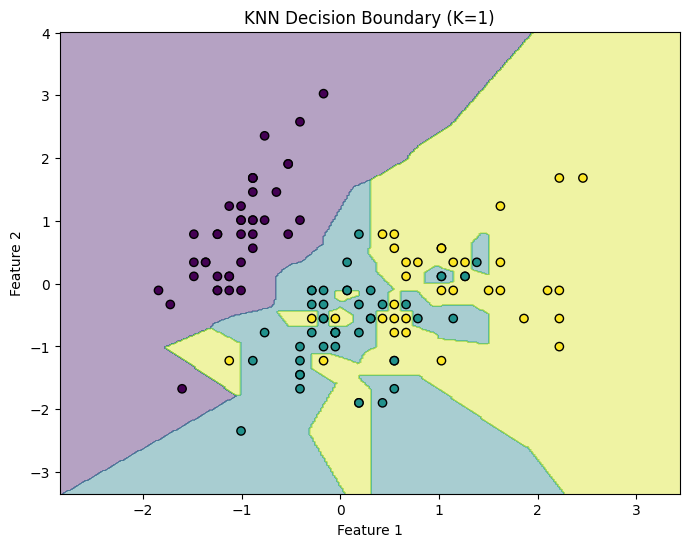


Task Completed Successfully!


In [1]:
# ==========================================
# Task 6: K-Nearest Neighbors Classification
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# ==========================
# Load Dataset
# ==========================

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(X, columns=iris.feature_names)
df["target"] = y

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# ==========================
# Train Test Split
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================
# Feature Normalization
# ==========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==========================
# Experiment with Different K
# ==========================

k_values = range(1, 16)
accuracy_scores = []

for k in k_values:

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    accuracy_scores.append(acc)

    print(f"K = {k}  Accuracy = {acc:.4f}")

# ==========================
# Best K
# ==========================

best_k = k_values[np.argmax(accuracy_scores)]

print("\nBest K:", best_k)

# ==========================
# Train Final Model
# ==========================

model = KNeighborsClassifier(n_neighbors=best_k)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ==========================
# Accuracy
# ==========================

accuracy = accuracy_score(y_test, y_pred)

print("\nFinal Accuracy:")
print(round(accuracy * 100, 2), "%")

# ==========================
# Confusion Matrix
# ==========================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ==========================
# Classification Report
# ==========================

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# ==========================
# Accuracy vs K Plot
# ==========================

plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    accuracy_scores,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K Value")

plt.grid(True)

plt.show()

# ==========================
# Decision Boundary
# ==========================
# Using only first 2 features
# for visualization
# ==========================

X_vis = iris.data[:, :2]
y_vis = iris.target

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
    X_vis,
    y_vis,
    test_size=0.2,
    random_state=42,
    stratify=y_vis
)

scaler_vis = StandardScaler()

X_train_v = scaler_vis.fit_transform(X_train_v)
X_test_v = scaler_vis.transform(X_test_v)

knn_vis = KNeighborsClassifier(n_neighbors=best_k)

knn_vis.fit(X_train_v, y_train_v)

# Create meshgrid

x_min = X_train_v[:, 0].min() - 1
x_max = X_train_v[:, 0].max() + 1

y_min = X_train_v[:, 1].min() - 1
y_max = X_train_v[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

Z = knn_vis.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.4)

scatter = plt.scatter(
    X_train_v[:, 0],
    X_train_v[:, 1],
    c=y_train_v,
    edgecolor='k'
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"KNN Decision Boundary (K={best_k})")

plt.show()

print("\nTask Completed Successfully!")